In [1]:
!pip install -q kagglehub

In [2]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "septa97/100k-courseras-course-reviews-dataset"
)

print(dataset_path)

100%|██████████| 12.2M/12.2M [00:00<00:00, 50.3MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/septa97/100k-courseras-course-reviews-dataset/versions/2


In [3]:
import pandas as pd
import os

In [4]:
print(os.listdir(dataset_path))

['reviews_by_course.csv', 'reviews.csv']


In [7]:
df = pd.read_csv(dataset_path + "/reviews_by_course.csv")

In [8]:
df.head()

,CourseId,Review,Label
0,2-speed-it,BOring,1
1,2-speed-it,Bravo !,5
2,2-speed-it,Very goo,5
3,2-speed-it,"Great course - I recommend it for all, especia...",5
4,2-speed-it,One of the most useful course on IT Management!,5


In [9]:
df.shape

(140320, 3)

In [10]:
df.columns

Index(['CourseId', 'Review', 'Label'], dtype='object')

In [11]:
df.isnull().sum()

,0
CourseId,0
Review,3
Label,0


In [12]:
df = df[["Review", "Label"]]

In [13]:
df = df.dropna()

In [14]:
df.head()

,Review,Label
0,BOring,1
1,Bravo !,5
2,Very goo,5
3,"Great course - I recommend it for all, especia...",5
4,One of the most useful course on IT Management!,5


In [15]:
import nltk
import string
from nltk.corpus import stopwords

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [16]:
stop_words = set(stopwords.words("english"))
def clean_text(text):
    text = str(text).lower()
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    words = text.split()
    cleaned_words = []
    for word in words:
        if word not in stop_words:
            cleaned_words.append(word)
    return " ".join(cleaned_words)
df["Clean_Review"] = df["Review"].apply(clean_text)

In [17]:
df.head()

,Review,Label,Clean_Review
0,BOring,1,boring
1,Bravo !,5,bravo
2,Very goo,5,goo
3,"Great course - I recommend it for all, especia...",5,great course recommend especially business man...
4,One of the most useful course on IT Management!,5,one useful course management


In [18]:
df["Label"].value_counts()

,count
Label,
5,106514
4,22460
3,5923
1,2866
2,2554


In [19]:
from collections import Counter
all_words = " ".join(df["Clean_Review"])
word_list = all_words.split()
word_frequency = Counter(word_list)
common_words = word_frequency.most_common(20)
print("Most Common Words\n")
for word, count in common_words:
    print(word, ":", count)

Most Common Words

course : 85026
great : 26556
good : 22906
really : 14008
excellent : 12510
de : 12167
learning : 11259
well : 10485
lot : 10030
curso : 9489
interesting : 8819
learn : 8632
would : 8472
much : 8237
que : 7613
thank : 7465
muy : 7398
like : 7381
useful : 7126
easy : 6764


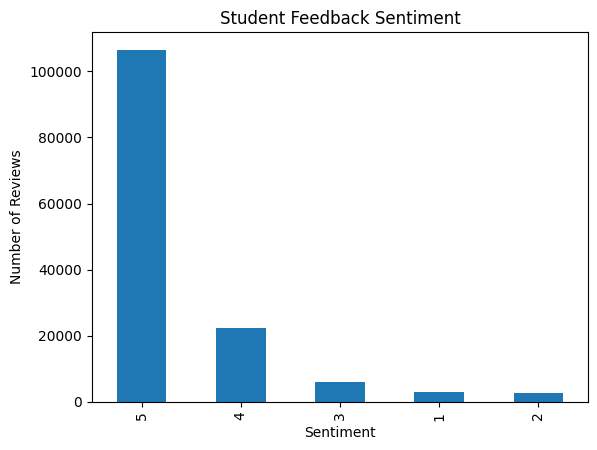

In [20]:
import matplotlib.pyplot as plt
df["Label"].value_counts().plot(
    kind="bar"
)
plt.title("Student Feedback Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [21]:
negative_feedback = df[
    (df["Label"] == "Negative") |
    (df["Label"] == "Very Negative")
]

negative_feedback.head(10)

,Review,Label,Clean_Review


In [22]:
print("Suggestions for Improvement")
print("1. Improve course explanations.")
print("2. Add more practical examples.")
print("3. Increase hands-on exercises.")
print("4. Improve video and audio quality.")
print("5. Provide quicker responses in discussion forums.")

Suggestions for Improvement
1. Improve course explanations.
2. Add more practical examples.
3. Increase hands-on exercises.
4. Improve video and audio quality.
5. Provide quicker responses in discussion forums.
